In [1]:

suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(platetools))
suppressPackageStartupMessages(library(patchwork))

Warning message:
“package ‘stringr’ was built under R version 4.2.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘platetools’ was built under R version 4.2.3”
Warning message:
“package ‘patchwork’ was built under R version 4.2.3”


In [2]:
platemap_file_path <- file.path("../../../data/2D_profiles/NF0040_T1/platemap/platemap.csv")
platemap <- read.csv(platemap_file_path, stringsAsFactors = FALSE)

In [3]:
# Add leading zeros if needed (uncomment the commented code in your notebook)
platemap <- platemap %>%
  mutate(well_position = str_replace(well_position, "([A-H])([1-9])$", "\\10\\2"))
platemap$dose_unit <- paste0(platemap$dose, " ", platemap$dose_unit)
head(platemap)


,WellRow,WellCol,well_position,treatment,dose,unit,dose_unit
,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>
1,B,2,B02,ARV-825,1,uM,1
2,C,2,C02,Staurosporine,10,nM,10
3,D,2,D02,Digoxin,1,uM,1
4,E,2,E02,Digoxin,1,uM,1
5,F,2,F02,Onalespib,1,uM,1
6,G,2,G02,Staurosporine,10,nM,10


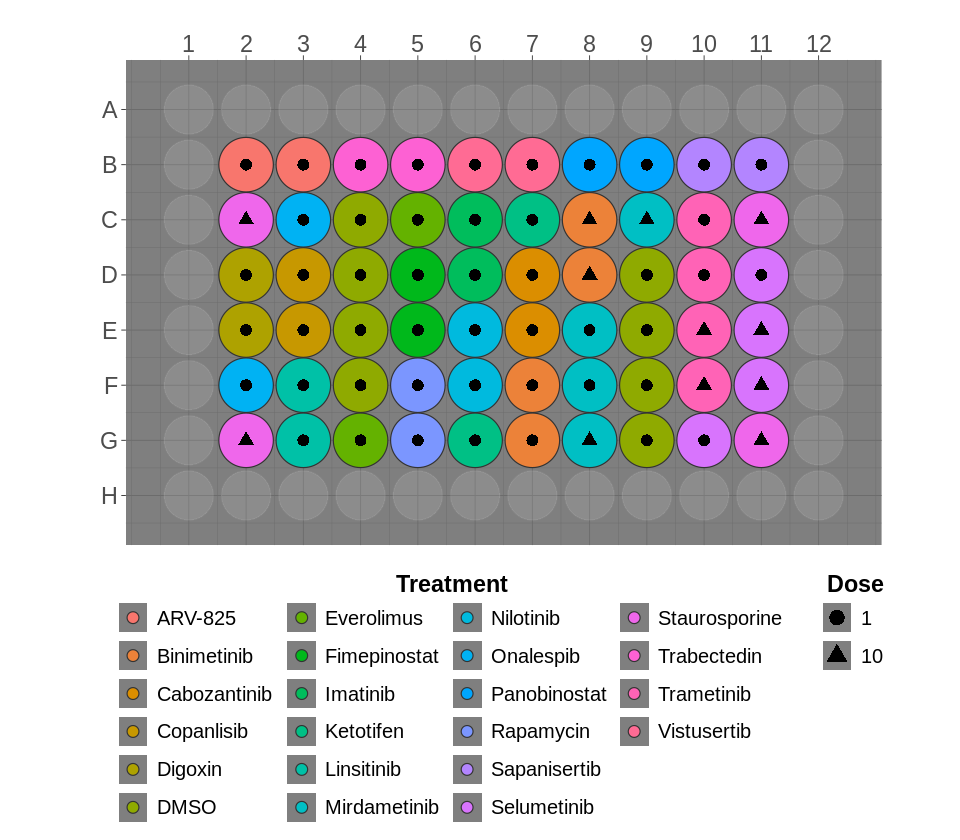

In [86]:
width <- 8
height <- 7
options(repr.plot.width = width, repr.plot.height = height)
font_size <- 16
axis_text_size <- font_size - 2
# Now create the plot
platemap_figure <- (
    platetools::raw_map(
        data = platemap$treatment,
        well = platemap$well_position,
        # shape = platemap$dose_unit,
        plate = 96,
        size = 15
    )
    + theme_dark()

    + theme(
        plot.title = element_text(size = 15, hjust = 0.5, face = "bold"),
        axis.text = element_text(size = axis_text_size),
        legend.position = "bottom",
        legend.title.position = "top",
        # make the legend go from left to right,
        legend.text = element_text(size = axis_text_size-2),
        legend.title = element_text(size = axis_text_size, face = "bold", hjust = 0.5)
        
        ) 
    + ggplot2::geom_point(aes(shape = platemap$dose_unit), size = 3)
    + ggplot2::scale_shape_discrete(name = "Dose")
    # make the legend three columns
    + guides(
        fill  = guide_legend(
            ncol = 4,
            override.aes = list(size = 3),
            title = "Treatment",
            order = 1,
            label.position = "right"
        ),
        shape = guide_legend(
            ncol = 1,
            override.aes = list(size = 4),
            title = "Dose",
            order = 2,
            label.position = "right"
        )
    )

)
ggsave(
    filename = file.path("../figures/platemap_figure.png"),
    plot = platemap_figure,
    width = width,
    height = height,
    units = "in",
    dpi = 600
)
platemap_figure